In [269]:
# =========================
# Standard Library
# =========================
import numpy as np
import pandas as pd
import os

# =========================
# KaggleHub
# =========================
import kagglehub

# =========================
# PyTorch
# =========================
import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import Dataset, DataLoader

# =========================
# Visualization
# =========================
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.figure_factory as ff
import plotly.graph_objects as go
import seaborn as sns

# =========================
# Machine Learning Utilities
# =========================
from sklearn.manifold import TSNE

# =========================
# Local Modules
# =========================
from model import *
from model_tab_transformer import *

## SKLEARN
from sklearn.preprocessing import OrdinalEncoder

from sklearn.metrics import (
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)
import numpy as np



# Download Dataset

In [270]:
# Download 
path = kagglehub.dataset_download("laotse/credit-risk-dataset")
file_path = os.path.join(path, "credit_risk_dataset.csv")
df = pd.read_csv(file_path)
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Features

- person_age: Age of the individual applying for the loan.
- person_income: Annual income of the individual.
- person_home_ownership: Type of home ownership of the individual.
    - rent: The individual is currently renting a property.
    - mortgage: The individual has a mortgage on the property they own.
    - own: The individual owns their home outright.
    - other: Other categories of home ownership that may be specific to the dataset.
- person_emp_length: Employment length of the individual in years.
- loan_intent: The intent behind the loan application.
- loan_amnt: The loan amount requested by the individual.
- loan_int_rate: The interest rate associated with the loan.
- loan_status: Loan status, where 0 indicates non-default and 1 indicates default.
    - 0: Non-default - The borrower successfully repaid the loan as agreed, and there was no default.
    - 1: Default - The borrower failed to repay the loan according to the agreed-upon terms and defaulted on the loan.
    - loan_percent_income: The percentage of income represented by the loan amount.
- cb_person_default_on_file: Historical default of the individual as per credit bureau records.
    - Y: The individual has a history of defaults on their credit file.
    - N: The individual does not have any history of defaults.
- cb_preson_cred_hist_length: The length of credit history for the individual.

## Age

In [271]:
#MAX AND MIN AGE
max_ = df['person_age'].max()
min_ = df['person_age'].min()
print(f"maximum Age {max_}")
print(f"minimum Age {min_}")

# people with an age between x and y
def age_group(arr):
    lenarr = len(arr)
    for i in range(0,lenarr-1):
        next = arr[i]+1
        num_people = df['person_age'].between(next,arr[i+1]).sum()
        print(f'Age between {next} and {arr[i+1]}: Number of people {num_people}')
        
age_group([0 ,18, 26, 36, 46, 56, 66])


maximum Age 144
minimum Age 20
Age between 1 and 18: Number of people 0
Age between 19 and 26: Number of people 17829
Age between 27 and 36: Number of people 11834
Age between 37 and 46: Number of people 2360
Age between 47 and 56: Number of people 434
Age between 57 and 66: Number of people 98


In [272]:
#dropping age above 80
df = df.drop(df[df['person_age'] > 80].index, axis=0)


In [273]:
df['age_group'] = pd.cut(df['person_age'],
                           bins=[20, 26, 36, 46, 56, 66],
                           labels=['20-25', '26-35', '36-45', '46-55', '56-65'])

In [274]:
df.drop('person_age', inplace=True, axis=1)

## Loan Grade

In [275]:
df.drop('loan_grade', inplace=True, axis=1)

## Income

In [276]:
#max and min income
max_ = df['person_income'].max()
min_ = df['person_income'].min()

print(f"maximum Income {max_}")
print(f"minimum Income {min_}")

#people with an income between x and y
def income_group(arr):
    lenarr = len(arr)
    for i in range(0,lenarr-1):
        next = arr[i]+1
        num_people = df['person_income'].between(next,arr[i+1]).sum()
        print(f'Income between {next} and {arr[i+1]}: Number of people {num_people}')
        
income_group([0, 25000, 50000, 75000, 100000,float('inf')])

maximum Income 2039784
minimum Income 4000
Income between 1 and 25000: Number of people 2468
Income between 25001 and 50000: Number of people 11613
Income between 50001 and 75000: Number of people 9622
Income between 75001 and 100000: Number of people 4667
Income between 100001 and inf: Number of people 4204


In [277]:
df['income_group'] = pd.cut(df['person_income'],
                              bins=[0, 25000, 50000, 75000, 100000, float('inf')],
                              labels=['low', 'low-middle', 'middle', 'high-middle', 'high'])

In [278]:
df.drop('person_income', inplace=True, axis=1)

In [279]:
df.head()

,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group,income_group
0,RENT,123.0,PERSONAL,35000,16.02,1,0.59,Y,3,20-25,middle
1,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2,20-25,low
2,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3,20-25,low
3,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2,20-25,middle
4,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4,20-25,middle


## Loan Amount

In [280]:
#min and max loan amount
max_loan_amount = df['loan_amnt'].max()
min_loan_amount = df['loan_amnt'].min()

print(f"maximum Loan Amount {max_loan_amount}")
print(f"minimum Loan Amount {min_loan_amount}")

# people with an income between x and y
def loan_amount_group(arr):
    lenarr = len(arr)
    for i in range(0,lenarr-1):
        next = arr[i]+1
        num_people = df['loan_amnt'].between(next,arr[i+1]).sum()
        print(f'Loan Amount between {next} and {arr[i+1]}: Number of people {num_people}')
        
loan_amount_group([0, 5000, 10000, 15000, float('inf')])

maximum Loan Amount 35000
minimum Loan Amount 500
Loan Amount between 1 and 5000: Number of people 9487
Loan Amount between 5001 and 10000: Number of people 12037
Loan Amount between 10001 and 15000: Number of people 6123
Loan Amount between 15001 and inf: Number of people 4927


In [281]:
df['loan_amount_group'] = pd.cut(df['loan_amnt'],
                                   bins=[0, 5000, 10000, 15000, float('inf')],
                                   labels=['small', 'medium', 'large', 'very large'])

In [282]:
df['loan_amount_group']

0        very large
1             small
2            medium
3        very large
4        very large
            ...    
32576        medium
32577    very large
32578    very large
32579         large
32580        medium
Name: loan_amount_group, Length: 32574, dtype: category
Categories (4, object): ['small' < 'medium' < 'large' < 'very large']

In [283]:
df.drop('loan_amnt', inplace=True, axis=1)

## Person Employment Length

In [284]:
df = df.drop(df[df['person_emp_length'] > 60].index, axis=0)

## Home ownership

In [285]:
level_counts=df.person_home_ownership.value_counts()
fig=px.pie(values=level_counts.values,
          names=level_counts.index,
          color_discrete_sequence=px.colors.sequential.Mint,
          title= 'person_home_ownership'
          )
fig.update_traces(textinfo='label+percent+value', textfont_size=13,
                  marker=dict(line=dict(color='#102000', width=0.2)))

fig.data[0].marker.line.width = 2
fig.data[0].marker.line.color='gray'
fig.show()


## Loan Intent

In [286]:
fig=px.histogram(df, x = 'loan_intent',histnorm = 'percent', text_auto = '.2f',template = 'presentation', title = 'loan intent',color_discrete_sequence=px.colors.sequential.Mint)
fig.update_layout()
fig.show()

## Credit History Length

In [287]:
fig=px.histogram(df, x = 'cb_person_cred_hist_length', text_auto = '.2f',template = 'presentation', title = 'person credit history length',color_discrete_sequence=px.colors.sequential.Mint)
fig.update_layout()
fig.show()


## Default on File

In [288]:
df.head()

,person_home_ownership,person_emp_length,loan_intent,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,age_group,income_group,loan_amount_group
1,OWN,5.0,EDUCATION,11.14,0,0.10,N,2,20-25,low,small
2,MORTGAGE,1.0,MEDICAL,12.87,1,0.57,N,3,20-25,low,medium
3,RENT,4.0,MEDICAL,15.23,1,0.53,N,2,20-25,middle,very large
4,RENT,8.0,MEDICAL,14.27,1,0.55,Y,4,20-25,middle,very large
5,OWN,2.0,VENTURE,7.14,1,0.25,N,2,20-25,low,small


In [289]:
df.drop('cb_person_default_on_file', inplace=True, axis=1)

# Missing Values

In [290]:
df.isnull().sum()

person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_int_rate                 3114
loan_status                      0
loan_percent_income              0
cb_person_cred_hist_length       0
age_group                       34
income_group                     0
loan_amount_group                0
dtype: int64

In [291]:
df.dropna(inplace=True)

In [292]:
df.shape

(28601, 10)

In [293]:
df.isnull().sum()

person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_cred_hist_length    0
age_group                     0
income_group                  0
loan_amount_group             0
dtype: int64

# Describe

In [294]:
df.describe(include='all')

,person_home_ownership,person_emp_length,loan_intent,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length,age_group,income_group,loan_amount_group
count,28601,28601.000000,28601,28601.00000,28601.000000,28601.000000,28601.000000,28601,28601,28601
unique,4,NaN,6,NaN,NaN,NaN,NaN,5,5,4
top,RENT,NaN,EDUCATION,NaN,NaN,NaN,NaN,20-25,low-middle,medium
freq,14532,NaN,5698,NaN,NaN,NaN,NaN,15666,10186,10598
mean,NaN,4.779903,NaN,11.03967,0.216706,0.169524,5.784029,NaN,NaN,NaN
std,NaN,4.029634,NaN,3.22952,0.412008,0.106374,4.012851,NaN,NaN,NaN
min,NaN,0.000000,NaN,5.42000,0.000000,0.000000,2.000000,NaN,NaN,NaN
25%,NaN,2.000000,NaN,7.90000,0.000000,0.090000,3.000000,NaN,NaN,NaN
50%,NaN,4.000000,NaN,10.99000,0.000000,0.150000,4.000000,NaN,NaN,NaN
75%,NaN,7.000000,NaN,13.48000,0.000000,0.230000,8.000000,NaN,NaN,NaN


In [295]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28601 entries, 1 to 32580
Data columns (total 10 columns):
 #   Column                      Non-Null Count  Dtype   
---  ------                      --------------  -----   
 0   person_home_ownership       28601 non-null  object  
 1   person_emp_length           28601 non-null  float64 
 2   loan_intent                 28601 non-null  object  
 3   loan_int_rate               28601 non-null  float64 
 4   loan_status                 28601 non-null  int64   
 5   loan_percent_income         28601 non-null  float64 
 6   cb_person_cred_hist_length  28601 non-null  int64   
 7   age_group                   28601 non-null  category
 8   income_group                28601 non-null  category
 9   loan_amount_group           28601 non-null  category
dtypes: category(3), float64(3), int64(2), object(2)
memory usage: 1.8+ MB


# Train Val Test Split

In [296]:
X = df.drop(['loan_status'], axis=1)
Y = df['loan_status']

In [297]:
from sklearn.model_selection import train_test_split

# Step 1: Train + Temp (val + test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, Y, test_size=0.3, random_state=12
)

# Step 2: Split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=12
)

In [298]:
print(f'Train: {len(y_train)}')
print(f'Val: {len(y_val)}')
print(f'Test: {len(y_test)}')

Train: 20020
Val: 4290
Test: 4291


## Numerical and Categorical Columns

In [299]:
# Numerical columns: 4
# Categorical columns: 5
numerical_columns = ['person_emp_length', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']
categorical_columns = ['person_home_ownership', 'loan_intent', 'age_group', 'income_group', 'loan_amount_group']

In [300]:
## Making Lookup table of categorical features and target
## Using sklearn.preprocessing.OrdinalEncoder
oe = OrdinalEncoder(handle_unknown='error',dtype=np.int64)

encoded = oe.fit_transform(X_train[categorical_columns].values)
X_train[categorical_columns] = encoded

In [301]:
X_train

,person_home_ownership,person_emp_length,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,age_group,income_group,loan_amount_group
9204,3,2.0,0,10.39,0.25,2,0,2,2
11549,3,1.0,0,11.86,0.15,3,0,4,1
16188,0,3.0,0,10.59,0.30,3,0,3,1
13686,3,3.0,3,7.66,0.22,4,0,4,0
22431,3,12.0,3,11.36,0.15,9,1,3,1
...,...,...,...,...,...,...,...,...,...
8457,0,6.0,0,15.62,0.29,3,0,4,0
22422,0,11.0,3,10.99,0.07,6,1,4,2
29570,3,2.0,1,8.90,0.08,13,1,3,2
6644,3,2.0,1,7.42,0.11,3,0,4,1


In [302]:
X_val[categorical_columns] = oe.transform(X_val[categorical_columns].values)
X_test[categorical_columns] = oe.transform(X_test[categorical_columns].values)

encoder_categories = oe.categories_
encoder_categories

[array(['MORTGAGE', 'OTHER', 'OWN', 'RENT'], dtype=object),
 array(['DEBTCONSOLIDATION', 'EDUCATION', 'HOMEIMPROVEMENT', 'MEDICAL',
        'PERSONAL', 'VENTURE'], dtype=object),
 array(['20-25', '26-35', '36-45', '46-55', '56-65'], dtype=object),
 array(['high', 'high-middle', 'low', 'low-middle', 'middle'], dtype=object),
 array(['large', 'medium', 'small', 'very large'], dtype=object)]

In [357]:
X_test.columns

Index(['person_home_ownership', 'person_emp_length', 'loan_intent',
       'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length',
       'age_group', 'income_group', 'loan_amount_group'],
      dtype='object')

In [328]:
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
import torch
import pandas as pd

# -----------------------------
# 1. Normalize continuous features
# -----------------------------
scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_val_scaled = X_val.copy()
X_test_scaled = X_test.copy()

if numerical_columns:
    # Fit on training data only
    X_train_scaled[numerical_columns] = scaler.fit_transform(X_train[numerical_columns])
    X_val_scaled[numerical_columns] = scaler.transform(X_val[numerical_columns])
    X_test_scaled[numerical_columns] = scaler.transform(X_test[numerical_columns])

# -----------------------------
# 2. TabularDataset with normalized numerical features
# -----------------------------
class TabularDataset(Dataset):
    def __init__(self, df, numerical_columns, categorical_columns, target=None):
        self.numerical_columns = numerical_columns
        self.categorical_columns = categorical_columns
        self.target = target

        # Continuous features (already scaled)
        if numerical_columns:
            self.numerical_data = torch.tensor(
                df[numerical_columns].values, dtype=torch.float32
            )
        else:
            self.numerical_data = None

        # Categorical features (integer encoded)
        if categorical_columns:
            self.categorical_data = torch.tensor(
                df[categorical_columns].values, dtype=torch.long
            )
        else:
            self.categorical_data = None

        # Labels
        if target is not None:
            self.labels = torch.tensor(df[target].values, dtype=torch.float32).unsqueeze(1)
        else:
            self.labels = None

    def __len__(self):
        return len(self.labels) if self.labels is not None else len(self.numerical_data)

    def __getitem__(self, idx):
        data = {}
        if self.numerical_data is not None:
            data['numerical'] = self.numerical_data[idx]
        if self.categorical_data is not None:
            data['categorical'] = self.categorical_data[idx]
        if self.labels is not None:
            return data, self.labels[idx]
        else:
            return data

# -----------------------------
# 3. Combine features + target for Dataset
# -----------------------------
train_df_scaled = pd.concat([X_train_scaled.reset_index(drop=True), y_train.reset_index(drop=True)], axis=1)
val_df_scaled   = pd.concat([X_val_scaled.reset_index(drop=True), y_val.reset_index(drop=True)], axis=1)
test_df_scaled  = pd.concat([X_test_scaled.reset_index(drop=True), y_test.reset_index(drop=True)], axis=1)

# -----------------------------
# 4. Dataset instances
# -----------------------------
train_ds = TabularDataset(train_df_scaled, numerical_columns, categorical_columns, target='loan_status')
val_ds   = TabularDataset(val_df_scaled, numerical_columns, categorical_columns, target='loan_status')
test_ds  = TabularDataset(test_df_scaled, numerical_columns, categorical_columns, target='loan_status')

# -----------------------------
# 5. DataLoaders
# -----------------------------
batch_size = 512
train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
val_dl   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
test_dl  = DataLoader(test_ds, batch_size=batch_size, shuffle=False)

In [329]:
# Example: get first sample
sample_data, sample_label = train_ds[1]

print("Numerical features:", sample_data['numerical'])
print("Categorical features:", sample_data['categorical'])
print("Label:", sample_label)

Numerical features: tensor([-0.9409,  0.2563, -0.1851, -0.6933])
Categorical features: tensor([3, 0, 0, 4, 1])
Label: tensor([0.])


In [362]:
# ------------------------------------------------
# MLP Block
# ------------------------------------------------
class MLPBlock(nn.Module):
    def __init__(self, n_features, hidden_units, dropout_rates):
        super().__init__()
        layers = []
        num_features = n_features
        for i, units in enumerate(hidden_units):
            layers.append(nn.BatchNorm1d(num_features))
            layers.append(nn.Linear(num_features, units))
            layers.append(nn.SELU())
            layers.append(nn.Dropout(dropout_rates[i]))
            num_features = units
        self.mlp_layers = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.mlp_layers(x)


# ------------------------------------------------
# TabTransformer Model (Multi-Head Attention + n_layers=6, d=32, n_heads=8)
# ------------------------------------------------
class TabTransformer(nn.Module):
    def __init__(self, categories, num_continuous, num_classes=2,
                 d=32, n_layers=6, n_heads=8,
                 dropout=0.1, mlp_hidden_units_factors=[4,2], mlp_dropout_rates=[0.2,0.2]):
        super().__init__()

        self.num_categories = len(categories)
        self.num_continuous = num_continuous
        self.emb_dim = d
        self.num_classes = num_classes

        # ----------------------------
        # Categorical Embeddings
        # ----------------------------
        self.embeddings = nn.ModuleList([
            nn.Embedding(num_classes_cat, d) for num_classes_cat in categories
        ])
        self.column_id = nn.Parameter(torch.randn(1, self.num_categories, d))

        # ----------------------------
        # Transformer Encoder Stack
        # ----------------------------
        self.transformers = nn.ModuleList([
            nn.TransformerEncoderLayer(
                d_model=d,
                nhead=n_heads,
                batch_first=True,
                dropout=dropout
            ) for _ in range(n_layers)
        ])

        # ----------------------------
        # MLP Head
        # ----------------------------
        self.n_features = (self.num_categories * d) + num_continuous
        mlp_hidden_units = [int(factor * self.n_features) for factor in mlp_hidden_units_factors]
        self.mlp = MLPBlock(self.n_features, mlp_hidden_units, mlp_dropout_rates)

        # Final dense layer outputs raw logits for CrossEntropyLoss
        self.final_dense = nn.Linear(mlp_hidden_units[-1], num_classes)

        # Layernorm for continuous features 
        self.num_norm = nn.LayerNorm(num_continuous) if num_continuous > 0 else None

    def forward(self, x_dict, return_embedding: bool = False):
        x_cat = x_dict.get('categorical', None)
        x_cont = x_dict.get('numerical', None)

        # ----------------------------
        # 1. Embed categorical features
        # ----------------------------
        if x_cat is not None:
            x = [embed(x_cat[:, i]) for i, embed in enumerate(self.embeddings)]
            x = torch.stack(x, dim=1)            # (batch, num_categories, d)
            x = x + self.column_id

            # ----------------------------
            # 2. Transformer encoding
            # ----------------------------
            for layer in self.transformers:
                x = layer(x)
            x_contextual = x.flatten(1)
        else:
            x_contextual = torch.zeros((x_cont.size(0), 0), device=x_cont.device)

        # ----------------------------
        # 3. Combine with continuous features
        # ----------------------------
        if x_cont is not None and x_cont.shape[-1] > 0:
            if self.num_norm is not None:
                x_cont = self.num_norm(x_cont)
            features = torch.cat([x_contextual, x_cont], dim=1)
        else:
            features = x_contextual

        # ----------------------------
        # 4. MLP + Raw logits for CrossEntropy
        # ----------------------------
        mlp_out = self.mlp(features)
        if return_embedding:
            return mlp_out  # return embedding before final dense layer

        logits = self.final_dense(mlp_out)  # shape: (batch_size, num_classes)
        return logits

In [363]:
# Assume categorical_columns and numerical_columns are defined
categories = [len(train_df_scaled[col].unique()) for col in categorical_columns]
num_cont = len(numerical_columns)
num_classes = 2  # loan_status binary classification

model = TabTransformer(categories, num_cont, num_classes=num_classes)

In [364]:
# Example batch
batch_data, batch_label = next(iter(train_dl))
logits = model(batch_data)
print(logits.shape)  # (batch_size, 2)

torch.Size([512, 2])


In [365]:
device = 'cpu'  
model = TabTransformer(
    categories=categories,
    num_continuous=num_cont,
    d=32,
    n_layers=6,
    n_heads=8,
    dropout=0.1
).to(device)

# CrossEntropyLoss expects raw logits 
criterion = nn.CrossEntropyLoss()

# Adam optimizer with L2 regularization
optimizer = optim.Adam(
    model.parameters(),
    lr=1e-3,
    weight_decay=1e-4
)

Epoch 1/50 | Train Loss: 0.5355 | Train Acc: 0.7292 | Val Loss: 0.4958 | Val Acc: 0.8119
Epoch 2/50 | Train Loss: 0.4488 | Train Acc: 0.7996 | Val Loss: 0.4576 | Val Acc: 0.7911
Epoch 3/50 | Train Loss: 0.4167 | Train Acc: 0.8146 | Val Loss: 0.3961 | Val Acc: 0.8368
Epoch 4/50 | Train Loss: 0.4094 | Train Acc: 0.8202 | Val Loss: 0.4037 | Val Acc: 0.8291
Epoch 5/50 | Train Loss: 0.4020 | Train Acc: 0.8220 | Val Loss: 0.3902 | Val Acc: 0.8291
Epoch 6/50 | Train Loss: 0.3928 | Train Acc: 0.8254 | Val Loss: 0.3834 | Val Acc: 0.8396
Epoch 7/50 | Train Loss: 0.3844 | Train Acc: 0.8309 | Val Loss: 0.3724 | Val Acc: 0.8443
Epoch 8/50 | Train Loss: 0.3866 | Train Acc: 0.8318 | Val Loss: 0.3767 | Val Acc: 0.8378
Epoch 9/50 | Train Loss: 0.3825 | Train Acc: 0.8311 | Val Loss: 0.3725 | Val Acc: 0.8427
Epoch 10/50 | Train Loss: 0.3806 | Train Acc: 0.8340 | Val Loss: 0.3753 | Val Acc: 0.8410
Epoch 11/50 | Train Loss: 0.3780 | Train Acc: 0.8349 | Val Loss: 0.3877 | Val Acc: 0.8343
Epoch 12/50 | Train

/opt/anaconda3/envs/stdevlib2/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.

/opt/anaconda3/envs/stdevlib2/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning:

use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.



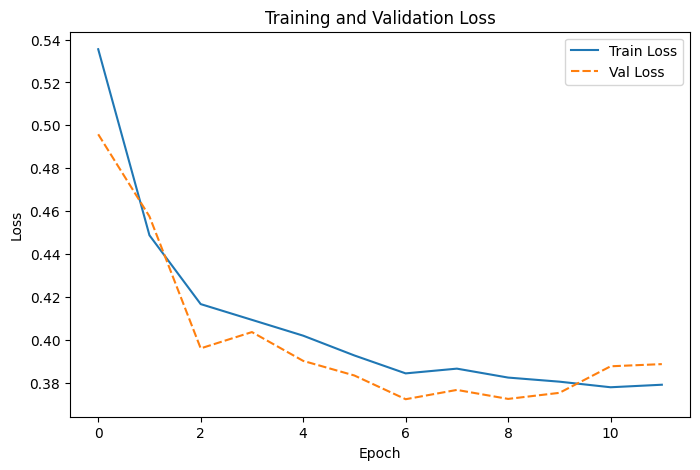

In [366]:
# ------------------------------------------------
# 5. Training Loop with Early Stopping + Loss Tracking
# ------------------------------------------------

num_epochs = 50
patience = 5

best_val_loss = float('inf')
patience_counter = 0

# Lists to store losses per epoch
train_losses = []
val_losses = []

for epoch in range(num_epochs):
    
    # ----------------------------
    # Training Phase
    # ----------------------------
    model.train()
    total_loss = 0
    total_correct = 0
    total_samples = 0

    for batch in train_dl:
        x_dict, y = batch
        x_dict = {k: v.to(device) for k, v in x_dict.items()}
        y = y.to(device).long().squeeze()

        optimizer.zero_grad()
        logits = model(x_dict)
        loss = criterion(logits, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * y.size(0)
        preds = logits.argmax(dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += y.size(0)

    avg_train_loss = total_loss / total_samples
    train_accuracy = total_correct / total_samples
    train_losses.append(avg_train_loss)

    # ----------------------------
    # Validation Phase
    # ----------------------------
    model.eval()
    val_loss = 0
    val_correct = 0
    val_samples = 0

    with torch.no_grad():
        for batch in val_dl:
            x_dict, y = batch
            x_dict = {k: v.to(device) for k, v in x_dict.items()}
            y = y.to(device).long().squeeze()

            logits = model(x_dict)
            loss = criterion(logits, y)

            val_loss += loss.item() * y.size(0)
            preds = logits.argmax(dim=1)
            val_correct += (preds == y).sum().item()
            val_samples += y.size(0)

    avg_val_loss = val_loss / val_samples
    val_accuracy = val_correct / val_samples
    val_losses.append(avg_val_loss)

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f}"
    )

    # ----------------------------
    # Early Stopping Logic
    # ----------------------------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "best_tabtransformer.pth")
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

# ------------------------------------------------
# Plot Training & Validation Losses
# ------------------------------------------------
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

losses = pd.DataFrame({'Train Loss': train_losses, 'Val Loss': val_losses})
plt.figure(figsize=(8,5))
sns.lineplot(data=losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.show()

In [372]:
def predict(
    model: nn.Module, 
    dataloader: DataLoader, 
    device: Optional[str] = None, 
    return_proba: bool = True,
    temperature: float = 1.0,
    threshold: float = 0.5  # <-- new argument
) -> Union[np.ndarray, Tuple[np.ndarray, np.ndarray, np.ndarray]]:
    """
    Predict default risk using a trained TabTransformer model.

    Args:
        model (nn.Module): Trained TabTransformer.
        dataloader (DataLoader): PyTorch DataLoader providing batches.
        device (str, optional): 'cpu' or 'cuda'. If None, auto-detect.
        return_proba (bool): Whether to return class probabilities and default probability.
        temperature (float): Softmax temperature. >1 for softer, <1 for sharper probabilities.
        threshold (float): Probability threshold for class 1 prediction.

    Returns:
        preds (np.ndarray): predicted class indices using threshold
        probs (np.ndarray, optional): class probabilities (N, 2)
        default_prob (np.ndarray, optional): probability of class 1
    """
    if device is None:
        device = next(model.parameters()).device

    model.to(device)
    model.eval()

    all_preds = []
    all_probs = []
    all_default_prob = []

    with torch.no_grad():
        for batch in dataloader:
            if isinstance(batch, (list, tuple)):
                x_dict = batch[0]
            else:
                x_dict = batch
            x_dict = {k: v.to(device) for k, v in x_dict.items()}

            logits = model(x_dict)  # (batch_size, 2)
            scaled_logits = logits / temperature
            probs = torch.softmax(scaled_logits, dim=1)
            default_prob = probs[:, 1]

            # --- Use threshold instead of argmax ---
            preds = (default_prob >= threshold).long()

            all_preds.append(preds.cpu())
            if return_proba:
                all_probs.append(probs.cpu())
                all_default_prob.append(default_prob.cpu())

    all_preds = torch.cat(all_preds).numpy()
    if return_proba:
        all_probs = torch.cat(all_probs).numpy()
        all_default_prob = torch.cat(all_default_prob).numpy()
        return all_preds, all_probs, all_default_prob
    else:
        return all_preds

In [389]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import numpy as np

# --- 1. Get predictions and default probabilities ---
preds, probs, default_prob = predict(model, test_dl, device=device, return_proba=True, temperature=1.0)

y_true = y_test.values  # or .to_numpy() if it's a DataFrame

# --- 2. Determine optimal threshold using ROC curve ---
fpr, tpr, thresholds = roc_curve(y_true, default_prob)
# Youden's J statistic: J = TPR - FPR
J = tpr - fpr
idx = np.argmax(J)
optimal_threshold = thresholds[idx]
print(f"Optimal probability threshold (Youden's J): {optimal_threshold:.4f}")

# --- 3. Convert probabilities to class predictions using threshold ---
preds_thresholded = (default_prob >= optimal_threshold).astype(int)

# --- 4. Metrics ---
accuracy = accuracy_score(y_true, preds_thresholded)
precision = precision_score(y_true, preds_thresholded)
recall = recall_score(y_true, preds_thresholded)
f1 = f1_score(y_true, preds_thresholded)
roc_auc = roc_auc_score(y_true, default_prob)
tn, fp, fn, tp = confusion_matrix(y_true, preds_thresholded).ravel()

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC AUC: {roc_auc:.4f}")
print(f"Confusion Matrix: TN={tn}, FP={fp}, FN={fn}, TP={tp}")

Optimal probability threshold (Youden's J): 0.2669
Accuracy: 0.7779
Precision: 0.4933
Recall: 0.7452
F1-score: 0.5936
ROC AUC: 0.8417
Confusion Matrix: TN=2642, FP=715, FN=238, TP=696


In [383]:
optimal_threshold

0.26689795

In [374]:
import pandas as pd

# --- Determine threshold (optional: from ROC / Youden's J) ---
# Example: default 0.5 or use optimal_threshold from ROC analysis
threshold_hard = optimal_threshold
threshold_soft = optimal_threshold # threshold is applied even on softened probabilities

# --- Predictions with threshold ---
preds_hard, probs_hard, default_prob_hard = predict(
    model, test_dl, device=device, temperature=1.0, threshold=threshold_hard
)

preds_soft, probs_soft, default_prob_soft = predict(
    model, test_dl, device=device, temperature=10.0, threshold=threshold_soft
)

# --- Create comparison table (first 20 samples) ---
df_preview = pd.DataFrame({
    "Predicted Class (hard)": preds_hard[:20],
    "Default Prob (hard)": default_prob_hard[:20],
    "Default Prob (soft)": default_prob_soft[:20],
    "Prob Class 0 (hard)": probs_hard[:20, 0],
    "Prob Class 1 (hard)": probs_hard[:20, 1],
    "Prob Class 0 (soft)": probs_soft[:20, 0],
    "Prob Class 1 (soft)": probs_soft[:20, 1],
})

df_preview

,Predicted Class (hard),Default Prob (hard),Default Prob (soft),Prob Class 0 (hard),Prob Class 1 (hard),Prob Class 0 (soft),Prob Class 1 (soft)
0,0,0.132575,0.453178,0.867425,0.132575,0.546822,0.453178
1,0,0.156650,0.458015,0.843350,0.156650,0.541985,0.458015
2,0,0.140097,0.454762,0.859903,0.140097,0.545238,0.454762
3,1,0.338462,0.483252,0.661538,0.338462,0.516748,0.483252
4,0,0.047456,0.425574,0.952544,0.047456,0.574426,0.425574
5,0,0.236489,0.470733,0.763511,0.236489,0.529267,0.470733
6,0,0.063558,0.433149,0.936442,0.063558,0.566851,0.433149
7,1,0.484936,0.498493,0.515064,0.484936,0.501507,0.498493
8,1,0.485871,0.498587,0.514129,0.485871,0.501413,0.498587
9,0,0.042544,0.422780,0.957456,0.042544,0.577220,0.422780


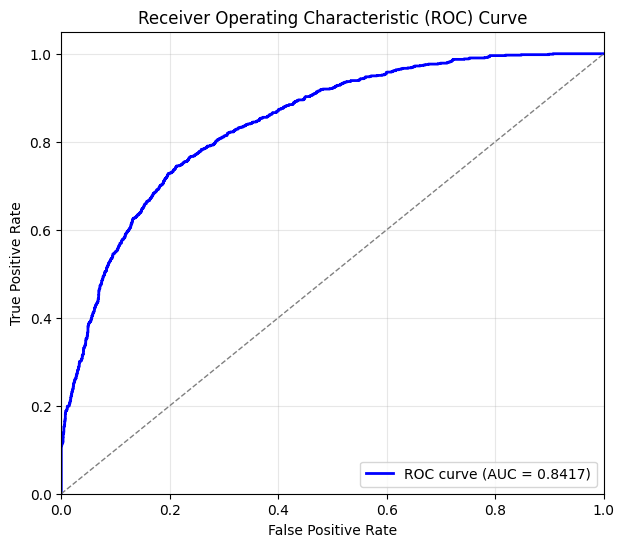

In [375]:
from sklearn.metrics import roc_curve, auc
# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_true, default_prob)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')  # diagonal line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

# TSNE

Optimal default probability threshold: 0.2669


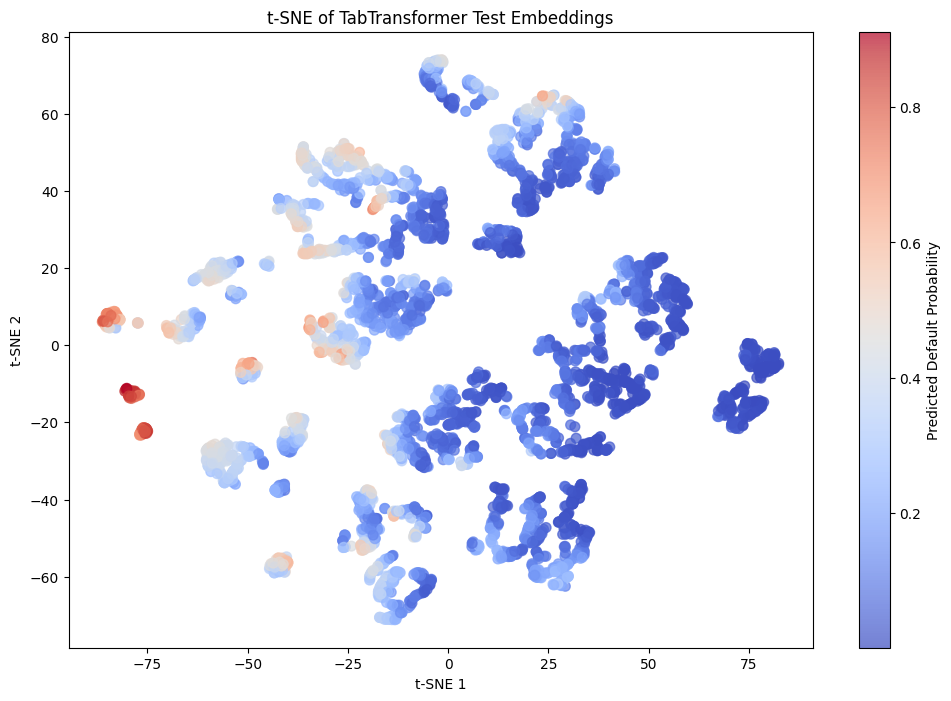

In [384]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import torch
import numpy as np

# -----------------------------
# 1. Collect embeddings and default probabilities
# -----------------------------
all_embeddings = []
all_default_prob = []

for x_dict, _ in test_dl:
    x_dict = {k: v.to(device) for k, v in x_dict.items()}
    
    # Get embeddings and logits
    emb = model(x_dict, return_embedding=True)  # (batch_size, embedding_dim)
    logits = model(x_dict)                      # (batch_size, 2)
    probs = torch.softmax(logits, dim=1)
    default_prob = probs[:, 1]                  # probability of default

    all_embeddings.append(emb.detach().cpu())
    all_default_prob.append(default_prob.detach().cpu())

all_embeddings = torch.cat(all_embeddings).numpy()
all_default_prob = torch.cat(all_default_prob).numpy()

# -----------------------------
# 2. t-SNE on embeddings
# -----------------------------
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
emb_2d = tsne.fit_transform(all_embeddings)

# -----------------------------
# 3. Determine optimal threshold (from ROC)
# -----------------------------
y_true = y_test.values
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_true, all_default_prob)
J = tpr - fpr
optimal_idx = np.argmax(J)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal default probability threshold: {optimal_threshold:.4f}")

# -----------------------------
# 4. Class predictions using threshold
# -----------------------------
preds_thresholded = (all_default_prob >= optimal_threshold).astype(int)

# -----------------------------
# 5. Plot t-SNE colored by default probability
# -----------------------------
plt.figure(figsize=(12,8))
scatter = plt.scatter(
    emb_2d[:,0], emb_2d[:,1],
    c=all_default_prob,            # color by predicted default probability
    cmap='coolwarm', 
    s=50,
    alpha=0.7
)
plt.colorbar(scatter, label='Predicted Default Probability')

# # Optional: annotate high-risk defaults above threshold
# for i, prob in enumerate(all_default_prob):
#     if prob >= optimal_threshold:
#         plt.text(emb_2d[i,0]+0.1, emb_2d[i,1]+0.1, f"{prob:.2f}", fontsize=8)

plt.title(f"t-SNE of TabTransformer Test Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.show()

In [388]:
category_label_maps

[{0: 'MORTGAGE', 1: 'OTHER', 2: 'OWN', 3: 'RENT'},
 {0: 'DEBTCONSOLIDATION',
  1: 'EDUCATION',
  2: 'HOMEIMPROVEMENT',
  3: 'MEDICAL',
  4: 'PERSONAL',
  5: 'VENTURE'},
 {0: '20-25', 1: '26-35', 2: '36-45', 3: '46-55', 4: '56-65'},
 {0: 'high', 1: 'high-middle', 2: 'low', 3: 'low-middle', 4: 'middle'},
 {0: 'large', 1: 'medium', 2: 'small', 3: 'very large'}]

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
import pandas as pd

# ----------------------------
# 1. Map encoded values back to human-readable labels
# ----------------------------
# encoder_categories is a list of arrays, one per categorical column
# Example: [array(['own', 'rent', 'mortgage', 'other'], dtype=object), ...]
cat_columns = categorical_columns  # e.g., ['person_home_ownership', 'person_emp_length', 'loan_intent']

# Build label lookup dictionaries
category_label_maps = []
for col_categories in encoder_categories:
    category_label_maps.append({i: val for i, val in enumerate(col_categories)})

# ----------------------------
# 2. Continuous features
# ----------------------------
cont_features = ['person_emp_length', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length']



In [392]:
preds = preds_thresholded

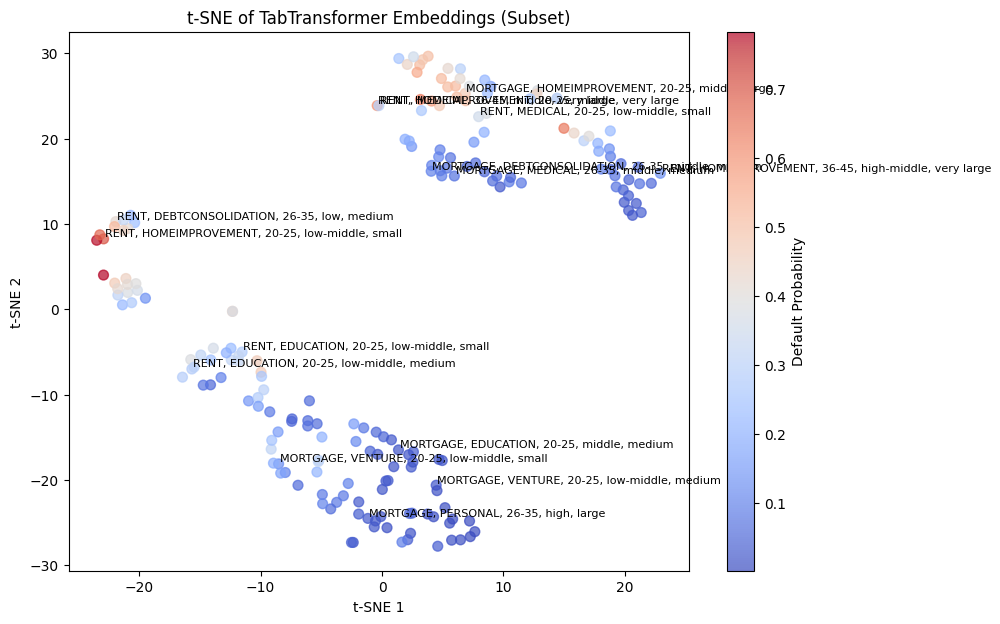

In [409]:
import numpy as np
import pandas as pd
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
import torch

# -----------------------------
# 1. Random subset of test indices
# -----------------------------
np.random.seed(42)
subset_size = 200  # adjust for visualization
subset_indices = np.random.choice(len(test_ds), size=subset_size, replace=False)

# -----------------------------
# 2. Collect embeddings and default probabilities for subset
# -----------------------------
subset_embeddings = []
subset_default_prob = []
subset_cat = []

for i in subset_indices:
    x_dict, y = test_ds[i]  # get single sample
    x_dict = {k: v.unsqueeze(0).to(device) for k, v in x_dict.items()}  # batch of 1
    
    # embeddings
    emb = model(x_dict, return_embedding=True)
    logits = model(x_dict)
    probs = torch.softmax(logits, dim=1)
    default_prob = probs[:, 1]
    
    subset_embeddings.append(emb.detach().cpu())
    subset_default_prob.append(default_prob.detach().cpu())
    
    # store categorical features
    subset_cat.append(x_dict['categorical'].cpu().numpy()[0])

subset_embeddings = torch.cat(subset_embeddings).numpy()
subset_default_prob = torch.cat(subset_default_prob).numpy()
subset_cat = np.array(subset_cat)

# -----------------------------
# 3. t-SNE
# -----------------------------
tsne = TSNE(n_components=2, random_state=42, perplexity=15)
emb_2d = tsne.fit_transform(subset_embeddings)

# -----------------------------
# 4. Build DataFrame for plotting
# -----------------------------
df = pd.DataFrame({
    'TSNE-1': emb_2d[:,0],
    'TSNE-2': emb_2d[:,1],
    'Default Prob': subset_default_prob
})

# Map human-readable categorical labels
for i, col in enumerate(categorical_columns):
    df[col] = [category_label_maps[i][val] for val in subset_cat[:,i]]

# -----------------------------
# 5. Plot t-SNE
# -----------------------------
plt.figure(figsize=(10,7))
scatter = plt.scatter(
    df['TSNE-1'], df['TSNE-2'],
    c=df['Default Prob'], cmap='coolwarm', s=50, alpha=0.7
)
plt.colorbar(scatter, label='Default Probability')
plt.title('t-SNE of TabTransformer Embeddings (Subset)')
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')

# Optional: annotate a few points (categorical values only)
for idx in range(min(15, subset_size)):
    # cat_str = ", ".join([f"{col}: {df[col].iloc[idx]}" for col in categorical_columns])
    cat_str = ", ".join([f"{df[col].iloc[idx]}" for col in categorical_columns])
    plt.text(df['TSNE-1'].iloc[idx]+0.1, df['TSNE-2'].iloc[idx]+0.25, cat_str, fontsize=8)

plt.show()

In [ ]:
# person_home_ownership, loan_intent, age_group, income_group, loan_amount_group